# Module 1 — Deep Models: Recurrent Neural Networks
## From Word Vectors to Sequence Models — A Hands-On PyTorch Tutorial
**Applied AI Mastery Program** | Rina Buoy, PhD

---

| Section | Topic | Slides |
|---------|-------|--------|
| §1 | Why order matters — bag-of-words fails on negation | 55–58 |
| §2 | Words as vectors — one-hot & learned embeddings | 57, 61 |
| §3 | The recurrent idea — $h_t = f(v_{w_t}, h_{t-1})$ | 58–63 |
| §4 | Which hidden state do we use? | 60 |
| §5 | Forward, backward & bidirectional RNNs | 62–66 |
| §6 | Deep (stacked) RNNs | 67 |
| §7 | RNN applications overview | 68 |
| §8 | Hands-on: sentiment classification | 69 |
| §9 | Hands-on: sequence labelling (POS tagging) | 70 |
| §10 | Hands-on: language modelling | 71 |
| §11 | LSTM/GRU & where CNN meets RNN (CRNN-OCR) | 54, 68 |

> This notebook continues directly from `Module_1_CNN_Tutorial.ipynb`, picking up at "Sequential Modelling" (slide 55).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('mps' if torch.backends.mps.is_available()
                       else ('cuda' if torch.cuda.is_available() else 'cpu'))
print('Using device:', device)


Using device: mps


---
## §1  Why Order Matters — Bag-of-Words Fails on Negation (Slides 55–58)

> Slide 56's motivating example:
> - *"The movie was **good, not bad**."* → positive
> - *"The movie was **bad, not good**."* → negative
>
> Both sentences contain the *exact same words*. A term-frequency (bag-of-words) vector — the
> "averaging" architecture on slide 58 — is **identical** for both sentences, so *no* classifier built
> on top of it can ever tell them apart. We need a representation that's sensitive to **order**.


In [2]:
def tokenize(sentence):
    return re.findall(r"[a-zA-Z']+", sentence.lower())

sent_pos = "The movie was good, not bad."
sent_neg = "The movie was bad, not good."

tokens_pos = tokenize(sent_pos)
tokens_neg = tokenize(sent_neg)
print('Tokens (positive):', tokens_pos)
print('Tokens (negative):', tokens_neg)

vocab = sorted(set(tokens_pos) | set(tokens_neg))

def term_freq_vector(tokens, vocab):
    return np.array([tokens.count(w) for w in vocab])

tf_pos = term_freq_vector(tokens_pos, vocab)
tf_neg = term_freq_vector(tokens_neg, vocab)

print('\nVocabulary        :', vocab)
print('TF vector positive :', tf_pos)
print('TF vector negative :', tf_neg)
print('\nAre the two bag-of-words vectors identical?', np.array_equal(tf_pos, tf_neg))
print('=> Any model built only on this vector is *mathematically incapable* of separating these two labels.')


Tokens (positive): ['the', 'movie', 'was', 'good', 'not', 'bad']
Tokens (negative): ['the', 'movie', 'was', 'bad', 'not', 'good']

Vocabulary        : ['bad', 'good', 'movie', 'not', 'the', 'was']
TF vector positive : [1 1 1 1 1 1]
TF vector negative : [1 1 1 1 1 1]

Are the two bag-of-words vectors identical? True
=> Any model built only on this vector is *mathematically incapable* of separating these two labels.


---
## §2  Words as Vectors — One-Hot Encoding & Learned Embeddings (Slides 57, 61)

> One-hot encoding (slide 57) gives every word an orthogonal, meaningless vector. An **embedding
> layer** (slide 61) is just a linear layer applied to the one-hot vector: $v_w = W_{emb}\,x^T$ — but
> in practice we skip the one-hot step and directly index into $W_{emb}$ with `nn.Embedding`.


In [3]:
# Slide 57 — one-hot encoding
mini_vocab = ['Rome', 'Paris', 'Italy', 'France']
word_to_idx = {w: i for i, w in enumerate(mini_vocab)}

one_hot = F.one_hot(torch.arange(len(mini_vocab)), num_classes=len(mini_vocab)).float()
for w, vec in zip(mini_vocab, one_hot):
    print(f'{w:>7} = {vec.int().tolist()}')


   Rome = [1, 0, 0, 0]
  Paris = [0, 1, 0, 0]
  Italy = [0, 0, 1, 0]
 France = [0, 0, 0, 1]


In [4]:
# Slide 61 — an embedding layer is a linear layer: v = W_emb @ x^T
embed_dim = 3
W_emb = torch.randn(embed_dim, len(mini_vocab))  # (embed_dim, vocab_size)

# Method 1: explicit matrix multiply with the one-hot vector
v_paris_manual = W_emb @ one_hot[word_to_idx['Paris']]

# Method 2: nn.Embedding lookup (what we use in practice — same computation, no one-hot needed)
embedding_layer = nn.Embedding(num_embeddings=len(mini_vocab), embedding_dim=embed_dim)
embedding_layer.weight.data = W_emb.T  # align weights: nn.Embedding stores (vocab_size, embed_dim)
v_paris_lookup = embedding_layer(torch.tensor(word_to_idx['Paris']))

print('v_paris via W_emb @ one_hot :', v_paris_manual.detach().numpy().round(3))
print('v_paris via nn.Embedding    :', v_paris_lookup.detach().numpy().round(3))
assert torch.allclose(v_paris_manual, v_paris_lookup, atol=1e-5)
print('\n✓ nn.Embedding lookup == one-hot @ W_emb (a linear layer, just implemented efficiently).')


v_paris via W_emb @ one_hot : [ 0.129 -0.186  0.267]
v_paris via nn.Embedding    : [ 0.129 -0.186  0.267]

✓ nn.Embedding lookup == one-hot @ W_emb (a linear layer, just implemented efficiently).


---
## §3  The Recurrent Idea (Slides 58–63)

> Instead of averaging word vectors (slide 58, order-blind), we fold them in one at a time, carrying
> a hidden state forward: $h_t = f(v_{w_t}, h_{t-1})$, with $h_0$ typically the zero vector (slide 63).
> Let's implement this update rule from scratch, then confirm it matches `nn.RNNCell` / `nn.RNN`.


In [5]:
def rnn_step_manual(v_t, h_prev, W_xh, W_hh, b):
    return np.tanh(v_t @ W_xh.T + h_prev @ W_hh.T + b)

embed_dim, hidden_dim = 4, 6
np.random.seed(1)
W_xh = np.random.randn(hidden_dim, embed_dim) * 0.3
W_hh = np.random.randn(hidden_dim, hidden_dim) * 0.3
b = np.zeros(hidden_dim)

T = 5
seq = np.random.randn(T, embed_dim)  # a toy sequence of T word embeddings

h = np.zeros(hidden_dim)  # h_0
hidden_states = []
for t in range(T):
    h = rnn_step_manual(seq[t], h, W_xh, W_hh, b)
    hidden_states.append(h)

print('Hidden state at every timestep (manual for-loop):')
for t, h_t in enumerate(hidden_states, start=1):
    print(f'  h_{t} = {h_t.round(3)}')


Hidden state at every timestep (manual for-loop):
  h_1 = [-0.525 -0.62   0.239  0.199 -0.324  0.649]
  h_2 = [-0.351  0.516 -0.244  0.004  0.183  0.487]
  h_3 = [ 0.919  0.723 -0.114  0.271  0.095 -0.9  ]
  h_4 = [ 0.376 -0.267  0.866  0.201 -0.379 -0.086]
  h_5 = [-0.461 -0.718 -0.085 -0.508  0.093  0.611]


In [6]:
# Cross-check against torch.nn.RNNCell (weights copied across so the math is identical)
cell = nn.RNNCell(input_size=embed_dim, hidden_size=hidden_dim, nonlinearity='tanh')
with torch.no_grad():
    cell.weight_ih.copy_(torch.tensor(W_xh, dtype=torch.float32))
    cell.weight_hh.copy_(torch.tensor(W_hh, dtype=torch.float32))
    cell.bias_ih.zero_(); cell.bias_hh.zero_()

h_t = torch.zeros(1, hidden_dim)
seq_t = torch.tensor(seq, dtype=torch.float32)
torch_hidden_states = []
for t in range(T):
    h_t = cell(seq_t[t].unsqueeze(0), h_t)
    torch_hidden_states.append(h_t.detach().numpy().flatten())

print('nn.RNNCell hidden states:')
for t, h_t_np in enumerate(torch_hidden_states, start=1):
    print(f'  h_{t} = {h_t_np.round(3)}')

max_diff = max(np.abs(a - b).max() for a, b in zip(hidden_states, torch_hidden_states))
print(f'\nMax abs difference vs. manual implementation: {max_diff:.2e}')
assert max_diff < 1e-5
print('✓ Manual recurrence matches nn.RNNCell exactly.')


nn.RNNCell hidden states:
  h_1 = [-0.525 -0.62   0.239  0.199 -0.324  0.649]
  h_2 = [-0.351  0.516 -0.244  0.004  0.183  0.487]
  h_3 = [ 0.919  0.723 -0.114  0.271  0.095 -0.9  ]
  h_4 = [ 0.376 -0.267  0.866  0.201 -0.379 -0.086]
  h_5 = [-0.461 -0.718 -0.085 -0.508  0.093  0.611]

Max abs difference vs. manual implementation: 1.31e-07
✓ Manual recurrence matches nn.RNNCell exactly.


In [7]:
# The whole sequence at once with nn.RNN (batch_first=True): input (N, T, D) -> output (N, T, H), h_T (1, N, H)
rnn = nn.RNN(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True)
with torch.no_grad():
    rnn.weight_ih_l0.copy_(torch.tensor(W_xh, dtype=torch.float32))
    rnn.weight_hh_l0.copy_(torch.tensor(W_hh, dtype=torch.float32))
    rnn.bias_ih_l0.zero_(); rnn.bias_hh_l0.zero_()

outputs, h_final = rnn(seq_t.unsqueeze(0))  # add batch dim
print('outputs shape (N, T, H):', tuple(outputs.shape), '-> one hidden state per timestep')
print('h_final shape (1, N, H):', tuple(h_final.shape), '-> just the last hidden state h_T')
assert torch.allclose(outputs[0, -1], h_final[0, 0], atol=1e-5)
print('h_T from outputs[:,-1,:] matches h_final:', True)


outputs shape (N, T, H): (1, 5, 6) -> one hidden state per timestep
h_final shape (1, N, H): (1, 1, 6) -> just the last hidden state h_T
h_T from outputs[:,-1,:] matches h_final: True


---
## §4  Which Hidden State Do We Use? (Slide 60)

> For a single prediction $\hat y$ from a whole sequence, we can feed a classifier $h_1$, $h_t$ (any
> middle step), $h_T$ (the last step — most common), or a pooled combination of all of them.


In [8]:
h_1 = outputs[0, 0]
h_mid = outputs[0, len(outputs[0]) // 2]
h_T = outputs[0, -1]
h_mean = outputs[0].mean(dim=0)     # mean-pool over all timesteps

print('h_1    (first word only)   :', h_1.detach().numpy().round(3))
print('h_mid  (some middle word)  :', h_mid.detach().numpy().round(3))
print('h_T    (last word, usual)  :', h_T.detach().numpy().round(3))
print('h_mean (average pooling)   :', h_mean.detach().numpy().round(3))
print('\nFor classification, h_T is standard: by the last step it has "seen" the whole sequence.')


h_1    (first word only)   : [-0.525 -0.62   0.239  0.199 -0.324  0.649]
h_mid  (some middle word)  : [ 0.919  0.723 -0.114  0.271  0.095 -0.9  ]
h_T    (last word, usual)  : [-0.461 -0.718 -0.085 -0.508  0.093  0.611]
h_mean (average pooling)   : [-0.008 -0.073  0.132  0.033 -0.067  0.152]

For classification, h_T is standard: by the last step it has "seen" the whole sequence.


---
## §5  Forward, Backward & Bidirectional RNNs (Slides 62–66)

> Reading left-to-right gives a **forward** RNN. Reading right-to-left gives a **backward** RNN.
> Concatenating both directions' hidden states at every position gives a **bidirectional** RNN —
> each position now has context from *both* the past and the future (slides 65–66).


In [9]:
# Backward RNN: reverse the sequence, run the same recurrence, re-reverse the outputs
reversed_seq = seq_t.flip(dims=[0])
backward_outputs, _ = rnn(reversed_seq.unsqueeze(0))
backward_outputs_realigned = backward_outputs.flip(dims=[1])

print('Forward  h_T (sees words 1..T):', outputs[0, -1].detach().numpy().round(3))
print('Backward h_1 (sees words T..1):', backward_outputs_realigned[0, 0].detach().numpy().round(3))


Forward  h_T (sees words 1..T): [-0.461 -0.718 -0.085 -0.508  0.093  0.611]
Backward h_1 (sees words T..1): [-0.5   -0.507  0.008  0.494 -0.427  0.58 ]


In [10]:
# Slides 65-66 — nn.RNN(bidirectional=True) does forward + backward in one call
bi_rnn = nn.RNN(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True, bidirectional=True)
bi_outputs, bi_h_final = bi_rnn(seq_t.unsqueeze(0))

print('Bidirectional outputs shape (N, T, 2H):', tuple(bi_outputs.shape))
print('Bidirectional h_final shape (2, N, H) — [forward_final, backward_final]:', tuple(bi_h_final.shape))

# Slide 66's [h_1^f, h_T^b] representation for position 1:
pos1_repr = torch.cat([bi_outputs[0, 0, :hidden_dim], bi_outputs[0, 0, hidden_dim:]])
print('Representation at position 1, [forward_h1, backward_h1] concatenated:', tuple(pos1_repr.shape))


Bidirectional outputs shape (N, T, 2H): (1, 5, 12)
Bidirectional h_final shape (2, N, H) — [forward_final, backward_final]: (2, 1, 6)
Representation at position 1, [forward_h1, backward_h1] concatenated: (12,)


---
## §6  Deep (Stacked) RNNs (Slide 67)

> Stacking recurrent layers — the output sequence of layer 1 becomes the input sequence of layer 2 —
> lets the network build higher-level temporal features, exactly like stacking conv layers builds
> higher-level spatial features.


In [11]:
deep_rnn = nn.RNN(input_size=embed_dim, hidden_size=hidden_dim, num_layers=3, batch_first=True)
outputs_deep, h_final_deep = deep_rnn(seq_t.unsqueeze(0))

print('Output sequence shape (N, T, H)         :', tuple(outputs_deep.shape), '<- only top layer\'s outputs')
print('Final hidden shape (num_layers, N, H)   :', tuple(h_final_deep.shape), '<- one h_T per layer')


Output sequence shape (N, T, H)         : (1, 5, 6) <- only top layer's outputs
Final hidden shape (num_layers, N, H)   : (3, 1, 6) <- one h_T per layer


---
## §7  RNN Applications Overview (Slide 68)

Sequential models apply anywhere data has an inherent order: stock prices, video frames, genomic
sequences (DNA base pairs), ECG signals, and climate time series. The rest of this notebook builds
three concrete task types straight from slides 69–71: **sentiment classification**, **sequence
labelling**, and **language modelling**.


---
## §8  Hands-On: Sentiment Classification (Slide 69)

> **Input:** a sequence of words. **Output:** probability of positive sentiment.
>
> We build a templated dataset around the exact "good, not bad" vs. "bad, not good" pattern from
> slide 56, generalized across many nouns and adjective pairs. Two models compete on it:
> 1. **Bag-of-words baseline** (slide 58's "averaging" architecture) — provably capped near 50% on
>    contrastive pairs, since it produces *identical* features for both classes (§1).
> 2. **RNN classifier** (`nn.Embedding` → `nn.RNN` → take $h_T$ → `nn.Linear`) — order-sensitive,
>    should learn to separate them.


In [12]:
nouns = ['movie', 'food', 'service', 'hotel', 'book', 'show', 'game', 'product', 'trip', 'concert']
adj_pairs = [('good', 'bad'), ('great', 'terrible'), ('amazing', 'awful'),
             ('excellent', 'poor'), ('wonderful', 'horrible')]

examples = []
for noun in nouns:
    for pos_adj, neg_adj in adj_pairs:
        examples.append((f"the {noun} was {pos_adj} , not {neg_adj} .", 1))
        examples.append((f"the {noun} was {neg_adj} , not {pos_adj} .", 0))

print(f'Total contrastive examples: {len(examples)}')
for sent, label in examples[:4]:
    print(f'  [{label}] {sent}')

# Build vocabulary
all_tokens = [tok for sent, _ in examples for tok in sent.split()]
vocab = ['<pad>'] + sorted(set(all_tokens))
word_to_idx = {w: i for i, w in enumerate(vocab)}
print(f'\nVocabulary size: {len(vocab)}')


Total contrastive examples: 100
  [1] the movie was good , not bad .
  [0] the movie was bad , not good .
  [1] the movie was great , not terrible .
  [0] the movie was terrible , not great .

Vocabulary size: 26


In [13]:
# Shuffle + split, holding the canonical slide-56 pair out as an extra sanity check
rng = np.random.RandomState(0)
perm = rng.permutation(len(examples))
examples_shuffled = [examples[i] for i in perm]

split = int(0.8 * len(examples_shuffled))
train_examples = examples_shuffled[:split]
test_examples = examples_shuffled[split:]
print(f'Train: {len(train_examples)}  Test: {len(test_examples)}')

canonical_pair = [
    ("the movie was good , not bad .", 1),
    ("the movie was bad , not good .", 0),
]


Train: 80  Test: 20


In [14]:
def encode(sentence, word_to_idx):
    return torch.tensor([word_to_idx[tok] for tok in sentence.split()], dtype=torch.long)

def make_batch(batch_examples, word_to_idx):
    seqs = [encode(s, word_to_idx) for s, _ in batch_examples]
    labels = torch.tensor([l for _, l in batch_examples], dtype=torch.float32)
    lengths = torch.tensor([len(s) for s in seqs])
    padded = pad_sequence(seqs, batch_first=True, padding_value=word_to_idx['<pad>'])
    return padded, lengths, labels

train_x, train_lengths, train_y = make_batch(train_examples, word_to_idx)
test_x, test_lengths, test_y = make_batch(test_examples, word_to_idx)
canon_x, canon_lengths, canon_y = make_batch(canonical_pair, word_to_idx)
print('Padded train batch shape:', tuple(train_x.shape))


Padded train batch shape: (80, 8)


In [15]:
# Baseline: slide 58's averaging architecture — embed every word, average, then a linear classifier.
# Since every contrastive pair has identical bag-of-words features, this is capped near 50% by construction.
class AveragingClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, x, lengths):
        emb = self.embedding(x)                                    # (N, T, D)
        mask = (x != 0).unsqueeze(-1).float()
        avg = (emb * mask).sum(1) / lengths.unsqueeze(-1).float()   # mean over real (non-pad) tokens
        return self.fc(avg).squeeze(-1)

def train_classifier(model, train_x, train_lengths, train_y, epochs=60, lr=1e-2):
    opt = optim.Adam(model.parameters(), lr=lr)
    history = []
    for _ in range(epochs):
        opt.zero_grad()
        logits = model(train_x, train_lengths)
        loss = F.binary_cross_entropy_with_logits(logits, train_y)
        loss.backward(); opt.step()
        history.append(loss.item())
    return history

def accuracy(model, x, lengths, y):
    with torch.no_grad():
        preds = (torch.sigmoid(model(x, lengths)) > 0.5).float()
        return (preds == y).float().mean().item()

bow_model = AveragingClassifier(len(vocab), embed_dim=16, pad_idx=word_to_idx['<pad>'])
bow_history = train_classifier(bow_model, train_x, train_lengths, train_y)

print(f'BoW-averaging train acc: {accuracy(bow_model, train_x, train_lengths, train_y):.3f}')
print(f'BoW-averaging test  acc: {accuracy(bow_model, test_x, test_lengths, test_y):.3f}')
print(f'BoW-averaging canonical-pair acc: {accuracy(bow_model, canon_x, canon_lengths, canon_y):.3f}  '
      f'(expected ~0.5 — features are identical for both sentences)')


BoW-averaging train acc: 0.575
BoW-averaging test  acc: 0.200
BoW-averaging canonical-pair acc: 0.500  (expected ~0.5 — features are identical for both sentences)


In [16]:
# RNN classifier: embed -> RNN -> take h_T -> linear. Order-sensitive, should beat the baseline.
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_T, _) = self.rnn(packed)   # h_T: (1, N, H) — last *real* token per sequence, padding-aware
        return self.fc(h_T[-1]).squeeze(-1)

rnn_model = RNNClassifier(len(vocab), embed_dim=16, hidden_dim=24, pad_idx=word_to_idx['<pad>'])
rnn_history = train_classifier(rnn_model, train_x, train_lengths, train_y, epochs=150, lr=1e-2)

print(f'RNN train acc: {accuracy(rnn_model, train_x, train_lengths, train_y):.3f}')
print(f'RNN test  acc: {accuracy(rnn_model, test_x, test_lengths, test_y):.3f}')
print(f'RNN canonical-pair acc: {accuracy(rnn_model, canon_x, canon_lengths, canon_y):.3f}  '
      f'(this is the exact "good, not bad" vs. "bad, not good" pair from slide 56)')


RNN train acc: 1.000
RNN test  acc: 1.000
RNN canonical-pair acc: 1.000  (this is the exact "good, not bad" vs. "bad, not good" pair from slide 56)


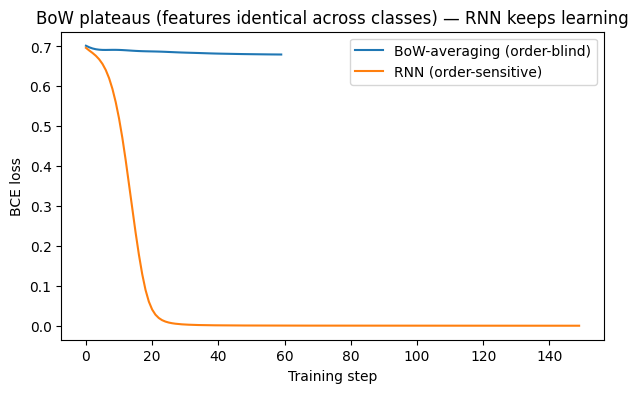

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(bow_history, label='BoW-averaging (order-blind)')
plt.plot(rnn_history, label='RNN (order-sensitive)')
plt.xlabel('Training step'); plt.ylabel('BCE loss'); plt.legend()
plt.title('BoW plateaus (features identical across classes) — RNN keeps learning')
plt.show()


---
## §9  Hands-On: Sequence Labelling — POS Tagging (Slide 70)

> **Input:** sequence of words. **Output:** a *sequence* of labels, one per word — not a single
> label for the whole sequence. Classical tasks: POS tagging, named-entity recognition, word
> segmentation. Architecture: `nn.Embedding` → `nn.RNN` (return every $h_t$) → `nn.Linear` applied
> at *every* timestep.


In [18]:
# A tiny hand-tagged toy dataset (DET/NOUN/VERB/ADJ/PUNCT)
tagged_sentences = [
    [("the", "DET"), ("cat", "NOUN"), ("sat", "VERB"), (".", "PUNCT")],
    [("a", "DET"), ("dog", "NOUN"), ("ran", "VERB"), (".", "PUNCT")],
    [("the", "DET"), ("food", "NOUN"), ("was", "VERB"), ("great", "ADJ"), (".", "PUNCT")],
    [("a", "DET"), ("movie", "NOUN"), ("was", "VERB"), ("bad", "ADJ"), (".", "PUNCT")],
    [("the", "DET"), ("big", "ADJ"), ("dog", "NOUN"), ("sat", "VERB"), (".", "PUNCT")],
    [("a", "DET"), ("small", "ADJ"), ("cat", "NOUN"), ("ran", "VERB"), (".", "PUNCT")],
    [("the", "DET"), ("show", "NOUN"), ("was", "VERB"), ("amazing", "ADJ"), (".", "PUNCT")],
    [("the", "DET"), ("trip", "NOUN"), ("was", "VERB"), ("wonderful", "ADJ"), (".", "PUNCT")],
] * 6  # repeat to give the tiny RNN enough gradient steps

pos_words = sorted({w for sent in tagged_sentences for w, _ in sent})
pos_word_to_idx = {w: i + 1 for i, w in enumerate(pos_words)}
pos_word_to_idx['<pad>'] = 0
pos_tags = sorted({t for sent in tagged_sentences for _, t in sent})
tag_to_idx = {t: i for i, t in enumerate(pos_tags)}

print('Word vocab:', pos_words)
print('Tag set   :', pos_tags)


Word vocab: ['.', 'a', 'amazing', 'bad', 'big', 'cat', 'dog', 'food', 'great', 'movie', 'ran', 'sat', 'show', 'small', 'the', 'trip', 'was', 'wonderful']
Tag set   : ['ADJ', 'DET', 'NOUN', 'PUNCT', 'VERB']


In [19]:
def encode_pos(sentence):
    words = torch.tensor([pos_word_to_idx[w] for w, _ in sentence], dtype=torch.long)
    tags = torch.tensor([tag_to_idx[t] for _, t in sentence], dtype=torch.long)
    return words, tags

word_seqs, tag_seqs = zip(*[encode_pos(s) for s in tagged_sentences])
word_lengths = torch.tensor([len(s) for s in word_seqs])
words_padded = pad_sequence(word_seqs, batch_first=True, padding_value=0)
tags_padded = pad_sequence(tag_seqs, batch_first=True, padding_value=-100)  # -100 ignored by cross_entropy

class POSTagger(nn.Module):
    def __init__(self, vocab_size, n_tags, embed_dim=16, hidden_dim=24):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.classifier = nn.Linear(hidden_dim, n_tags)  # applied at every timestep

    def forward(self, x):
        emb = self.embedding(x)
        outputs, _ = self.rnn(emb)          # (N, T, H) — a feature vector per position
        return self.classifier(outputs)     # (N, T, n_tags) — a label distribution per position

tagger = POSTagger(len(pos_word_to_idx), len(pos_tags))
opt = optim.Adam(tagger.parameters(), lr=1e-2)

for epoch in range(200):
    opt.zero_grad()
    logits = tagger(words_padded)                          # (N, T, n_tags)
    loss = F.cross_entropy(logits.transpose(1, 2), tags_padded)  # cross_entropy wants (N, C, T)
    loss.backward(); opt.step()

print(f'Final training loss: {loss.item():.4f}')


Final training loss: 0.0011


In [20]:
tagger.eval()
test_sentence = [("the", "?"), ("show", "?"), ("was", "?"), ("wonderful", "?"), (".", "?")]
test_words = torch.tensor([[pos_word_to_idx[w] for w, _ in test_sentence]])
with torch.no_grad():
    pred_logits = tagger(test_words)
    pred_tags = pred_logits.argmax(-1).squeeze(0)

idx_to_tag = {i: t for t, i in tag_to_idx.items()}
print('Sentence:', ' '.join(w for w, _ in test_sentence))
print('Predicted tags:', [idx_to_tag[i.item()] for i in pred_tags])


Sentence: the show was wonderful .
Predicted tags: ['DET', 'NOUN', 'VERB', 'ADJ', 'PUNCT']


---
## §10  Hands-On: Language Modelling (Slide 71)

> **Task:** predict the *next* word at every position — *"The food was great."* → given "The",
> predict "food"; given "The food", predict "was"; and so on. Train with **teacher forcing**:
> feed the true previous tokens, and cross-entropy against the true next token at every step.


In [21]:
lm_sentences = [
    "the food was great .",
    "the movie was good .",
    "the service was bad .",
    "the show was amazing .",
    "the trip was wonderful .",
    "the hotel was excellent .",
    "the game was terrible .",
    "the book was awful .",
] * 8

lm_tokens = [s.split() for s in lm_sentences]
lm_vocab = ['<pad>'] + sorted({tok for sent in lm_tokens for tok in sent})
lm_word_to_idx = {w: i for i, w in enumerate(lm_vocab)}
lm_idx_to_word = {i: w for w, i in lm_word_to_idx.items()}

lm_encoded = [torch.tensor([lm_word_to_idx[t] for t in sent]) for sent in lm_tokens]
lm_inputs = pad_sequence([s[:-1] for s in lm_encoded], batch_first=True, padding_value=0)
lm_targets = pad_sequence([s[1:] for s in lm_encoded], batch_first=True, padding_value=-100)

print(f'Vocabulary ({len(lm_vocab)} words):', lm_vocab)
print('Example input :', lm_tokens[0][:-1])
print('Example target:', lm_tokens[0][1:])


Vocabulary (20 words): ['<pad>', '.', 'amazing', 'awful', 'bad', 'book', 'excellent', 'food', 'game', 'good', 'great', 'hotel', 'movie', 'service', 'show', 'terrible', 'the', 'trip', 'was', 'wonderful']
Example input : ['the', 'food', 'was', 'great']
Example target: ['food', 'was', 'great', '.']


In [22]:
class WordLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=16, hidden_dim=32):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.classifier = nn.Linear(hidden_dim, vocab_size)  # a distribution over the *whole* vocab, per step

    def forward(self, x, h=None):
        emb = self.embedding(x)
        outputs, h = self.rnn(emb, h)
        return self.classifier(outputs), h

lm = WordLanguageModel(len(lm_vocab))
opt = optim.Adam(lm.parameters(), lr=1e-2)

for epoch in range(300):
    opt.zero_grad()
    logits, _ = lm(lm_inputs)
    loss = F.cross_entropy(logits.transpose(1, 2), lm_targets)
    loss.backward(); opt.step()

print(f'Final training loss: {loss.item():.4f}')


Final training loss: 0.5210


In [23]:
@torch.no_grad()
def generate(lm, seed_word, max_len=6):
    lm.eval()
    tokens = [lm_word_to_idx[seed_word]]
    h = None
    for _ in range(max_len - 1):
        x = torch.tensor([[tokens[-1]]])
        logits, h = lm(x, h)
        next_token = logits[0, -1].argmax().item()
        tokens.append(next_token)
        if lm_idx_to_word[next_token] == '.':
            break
    return ' '.join(lm_idx_to_word[t] for t in tokens)

for seed in ['the', 'movie', 'hotel']:
    # 'the' alone is ambiguous (many valid continuations); the greedy model will commit to its highest-probability path
    print(f'Seed: "{seed}" -> "{generate(lm, seed)}"')


Seed: "the" -> "the hotel was excellent ."
Seed: "movie" -> "movie was good ."
Seed: "hotel" -> "hotel was excellent ."


---
## §11  LSTM/GRU, and Where CNN Meets RNN (Slides 54, 68)

- **Vanilla RNNs** struggle with long sequences (vanishing/exploding gradients through repeated
  `tanh`/matrix-multiply steps). **LSTM** and **GRU** cells add gates that let gradients flow over
  many steps — §8's sentiment classifier already uses `nn.LSTM` as a drop-in replacement for `nn.RNN`.
- **CRNN for OCR** (slide 54, from the CNN notebook's §12 table): a CNN extracts a sequence of
  column-feature-vectors from an image, a **deep bidirectional LSTM** models dependencies across
  that sequence, and a transcription layer decodes the final character sequence — literally the
  concatenation of everything built in these two notebooks.


In [24]:
# Swapping nn.RNN for nn.GRU in the POS tagger — same interface, different internal gating
class POSTaggerGRU(nn.Module):
    def __init__(self, vocab_size, n_tags, embed_dim=16, hidden_dim=24):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.classifier = nn.Linear(hidden_dim, n_tags)

    def forward(self, x):
        emb = self.embedding(x)
        outputs, _ = self.rnn(emb)
        return self.classifier(outputs)

gru_tagger = POSTaggerGRU(len(pos_word_to_idx), len(pos_tags))
opt = optim.Adam(gru_tagger.parameters(), lr=1e-2)
for epoch in range(200):
    opt.zero_grad()
    logits = gru_tagger(words_padded)
    loss = F.cross_entropy(logits.transpose(1, 2), tags_padded)
    loss.backward(); opt.step()
print(f'GRU-based POS tagger final training loss: {loss.item():.4f}  (nn.RNN -> nn.GRU was a one-line swap)')


GRU-based POS tagger final training loss: 0.0009  (nn.RNN -> nn.GRU was a one-line swap)


---
## Recap

Starting from the exact motivating example on slide 56 — two sentences with identical bag-of-words
features but opposite meaning — we built the recurrent machinery needed to tell them apart:
embeddings, the recurrence $h_t = f(v_{w_t}, h_{t-1})$, bidirectional and stacked RNNs, and three
worked task types (sentiment classification, sequence labelling, language modelling). Together with
`Module_1_CNN_Tutorial.ipynb`, this covers every architecture on the lecture's 72 slides — right up
to the CRNN-OCR model that combines both.
